In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train_data.txt', delimiter=':::', engine='python', header=None)

In [3]:
# Multiclass classification problem

In [4]:
df.head()

,0,1,2,3
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [5]:
df[2].iloc[:100]

0            drama 
1         thriller 
2            adult 
3            drama 
4            drama 
          ...      
95     documentary 
96           drama 
97           drama 
98           drama 
99     documentary 
Name: 2, Length: 100, dtype: object

In [9]:
df['id'] = df.iloc[:][0]

In [10]:
df.drop([0], axis=1, inplace=True)

In [11]:
df.head()

,1,2,3,id
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...,1
1,Cupid (1997),thriller,A brother and sister with a past incestuous r...,2
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...,3
3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...,4
4,The Unrecovered (2007),drama,The film's title refers not only to the un-re...,5


In [12]:
df[1].iloc[:20]

0                         Oscar et la dame rose (2009) 
1                                         Cupid (1997) 
2                     Young, Wild and Wonderful (1980) 
3                                The Secret Sin (1915) 
4                               The Unrecovered (2007) 
5                               Quality Control (2011) 
6                                   "Pink Slip" (2009) 
7                                 One Step Away (1985) 
8                             "Desperate Hours" (2016) 
9                                     Spirits (2014/I) 
10                      The Spirit World: Ghana (2016) 
11                              In the Gloaming (1997) 
12                 Pink Ribbons: One Small Step (2009) 
13                                  Interrabang (1969) 
14                          The Glass Menagerie (1973) 
15                                   Night Call (2016) 
16                                Babylon Vista (2001) 
17     "Wo Grafen schlafen - Eine Schlösser-Reis

In [13]:
df['Movi_title'] = df.iloc[:][1]

In [14]:
df['Discription'] = df.iloc[:][3]

In [15]:
df.head()

,1,2,3,id,Movi_title,Discription
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...,1,Oscar et la dame rose (2009),Listening in to a conversation between his do...
1,Cupid (1997),thriller,A brother and sister with a past incestuous r...,2,Cupid (1997),A brother and sister with a past incestuous r...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...,3,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...
3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...,4,The Secret Sin (1915),To help their unemployed father make ends mee...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-re...,5,The Unrecovered (2007),The film's title refers not only to the un-re...


In [16]:
df.drop([1,3],axis=1,inplace=True)

In [17]:
df.head()

,2,id,Movi_title,Discription
0,drama,1,Oscar et la dame rose (2009),Listening in to a conversation between his do...
1,thriller,2,Cupid (1997),A brother and sister with a past incestuous r...
2,adult,3,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...
3,drama,4,The Secret Sin (1915),To help their unemployed father make ends mee...
4,drama,5,The Unrecovered (2007),The film's title refers not only to the un-re...


In [18]:
df['Genre']=df.iloc[:][2]

In [19]:
df = df.drop([2], axis=1)

In [20]:
df.head()

,id,Movi_title,Discription,Genre
0,1,Oscar et la dame rose (2009),Listening in to a conversation between his do...,drama
1,2,Cupid (1997),A brother and sister with a past incestuous r...,thriller
2,3,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...,adult
3,4,The Secret Sin (1915),To help their unemployed father make ends mee...,drama
4,5,The Unrecovered (2007),The film's title refers not only to the un-re...,drama


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           54214 non-null  int64 
 1   Movi_title   54214 non-null  object
 2   Discription  54214 non-null  object
 3   Genre        54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [27]:
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize

In [23]:
df['len_char'] = df['Discription'].apply(len)

In [28]:
df['len_word'] = df['Discription'].apply(lambda x:len(word_tokenize(x)))

In [29]:
df['len_sent.'] = df['Discription'].apply(lambda x:len(sent_tokenize(x)))

In [30]:
df.head()

,id,Movi_title,Discription,Genre,len_char,len_word,len_sent.
0,1,Oscar et la dame rose (2009),Listening in to a conversation between his do...,drama,546,105,4
1,2,Cupid (1997),A brother and sister with a past incestuous r...,thriller,184,34,2
2,3,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...,adult,650,129,7
3,4,The Secret Sin (1915),To help their unemployed father make ends mee...,drama,1082,216,9
4,5,The Unrecovered (2007),The film's title refers not only to the un-re...,drama,625,115,3


In [31]:
len(df['Genre'].unique())

27

In [32]:
df.head()

,id,Movi_title,Discription,Genre,len_char,len_word,len_sent.
0,1,Oscar et la dame rose (2009),Listening in to a conversation between his do...,drama,546,105,4
1,2,Cupid (1997),A brother and sister with a past incestuous r...,thriller,184,34,2
2,3,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...,adult,650,129,7
3,4,The Secret Sin (1915),To help their unemployed father make ends mee...,drama,1082,216,9
4,5,The Unrecovered (2007),The film's title refers not only to the un-re...,drama,625,115,3


In [ ]:
# sns.heatmap(df.corr(),annot=True)

In [33]:
# Download punkt tokenizer
nltk.download('punkt_tab')

# Download stopwords dataset
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

In [41]:
def preprocessing(text):
    if isinstance(text, str): 
        # Convert text to lowercase
        text = text.lower()
        # Remove possessive 's
        # re.replace(r'('\%)|[\s]' to remove character as mentioned
        text = text.replace("'s","")
        # Remove backticks and other symbols
        text = text.replace('`', '')
        # Tokenize text into words
        text = word_tokenize(text)
        # Remove punctuation, stopwords, and apply stemming
        y =[]
        for i in text:
            if i.isalnum():
                y.append(i)
        text = y[:]
        y.clear()
        for i in text:
            if i not in stop_words and i not in string.punctuation:
                y.append(ps.stem(i))
        return " ".join(y)
    # return text


In [43]:
df.head()

,id,Movi_title,Discription,Genre,len_char,len_word,len_sent.
0,1,Oscar et la dame rose (2009),Listening in to a conversation between his do...,drama,546,105,4
1,2,Cupid (1997),A brother and sister with a past incestuous r...,thriller,184,34,2
2,3,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...,adult,650,129,7
3,4,The Secret Sin (1915),To help their unemployed father make ends mee...,drama,1082,216,9
4,5,The Unrecovered (2007),The film's title refers not only to the un-re...,drama,625,115,3


C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


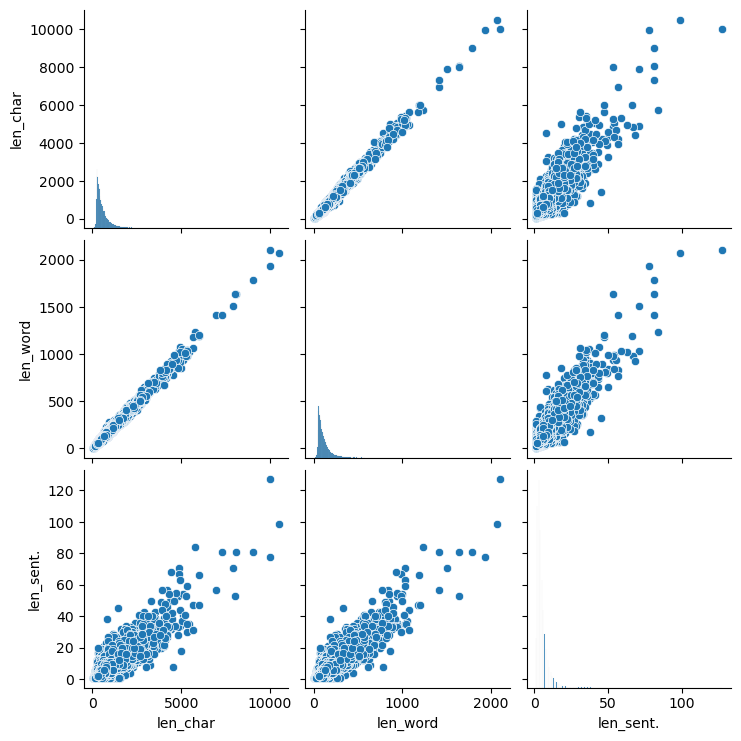

In [116]:
sns.pairplot(df)

In [49]:
df['Discription'] = df['Discription'].apply(preprocessing)

In [50]:
df.head()

,id,Movi_title,Discription,Genre,len_char,len_word,len_sent.
0,1,Oscar et la dame rose (2009),listen convers doctor parent oscar learn nobod...,drama,546,105,4
1,2,Cupid (1997),brother sister past incestu relationship curre...,thriller,184,34,2
2,3,"Young, Wild and Wonderful (1980)",bu empti student field trip museum natur histo...,adult,650,129,7
3,4,The Secret Sin (1915),help unemploy father make end meet edith twin ...,drama,1082,216,9
4,5,The Unrecovered (2007),film titl refer bodi ground zero also state na...,drama,625,115,3


In [51]:
df.drop(['Movi_title'],axis = 1,inplace=True)

In [52]:
df.drop(['id'],axis = 1,inplace=True)

In [53]:
new_df= df[['Discription','Genre']]

In [54]:
new_df.head()

,Discription,Genre
0,listen convers doctor parent oscar learn nobod...,drama
1,brother sister past incestu relationship curre...,thriller
2,bu empti student field trip museum natur histo...,adult
3,help unemploy father make end meet edith twin ...,drama
4,film titl refer bodi ground zero also state na...,drama


In [55]:
df['Genre'].unique()

array([' drama ', ' thriller ', ' adult ', ' documentary ', ' comedy ',
       ' crime ', ' reality-tv ', ' horror ', ' sport ', ' animation ',
       ' action ', ' fantasy ', ' short ', ' sci-fi ', ' music ',
       ' adventure ', ' talk-show ', ' western ', ' family ', ' mystery ',
       ' history ', ' news ', ' biography ', ' romance ', ' game-show ',
       ' musical ', ' war '], dtype=object)

In [53]:
# from sklearn.preprocessing import LabelEncoder

# label_encoder = LabelEncoder()
# df['genre'] = label_encoder.fit_transform(df['genre'])

# # Check the mapping
# print(dict(enumerate(label_encoder.classes_)))

{0: ' action ', 1: ' adult ', 2: ' adventure ', 3: ' animation ', 4: ' biography ', 5: ' comedy ', 6: ' crime ', 7: ' documentary ', 8: ' drama ', 9: ' family ', 10: ' fantasy ', 11: ' game-show ', 12: ' history ', 13: ' horror ', 14: ' music ', 15: ' musical ', 16: ' mystery ', 17: ' news ', 18: ' reality-tv ', 19: ' romance ', 20: ' sci-fi ', 21: ' short ', 22: ' sport ', 23: ' talk-show ', 24: ' thriller ', 25: ' war ', 26: ' western '}


In [54]:
# from sklearn.preprocessing import OneHotEncoder
# # Create an instance of the OneHotEncoder
# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# # Fit the encoder on the training data
# encoded_array_train = encoder.fit_transform(df[['genre']])

# # Convert the encoded array to a DataFrame
# encoded_df_train = pd.DataFrame(encoded_array_train, columns=encoder.get_feature_names_out(['genre']))

# # Concatenate the original training DataFrame with the new encoded columns and drop the old ones
# df = pd.concat([df, encoded_df_train], axis=1).drop(['genre'], axis=1)


In [138]:
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

In [140]:
# # Create a corpus from the 'info' column
# corpus = df['info'].tolist()

# # Display the corpus
# print(corpus)

In [184]:
# sns.pairplot(df)

([<matplotlib.patches.Wedge at 0x248f4323c50>,
 [Text(0.7751310052677347, 0.7804946666522656, ''),
  Text(-0.762411592605899, 0.7929240590751027, ''),
  Text(-1.0193079400360507, -0.41353515374084354, ''),
  Text(-0.4882199992075867, -0.9857186375298705, ''),
  Text(-0.04199629696967724, -1.0991980308574225, ''),
  Text(0.19879898575660607, -1.0818867608313474, ''),
  Text(0.3773134294046659, -1.0332640398227795, ''),
  Text(0.5139243650170421, -0.9725645207603609, ''),
  Text(0.6185204948981458, -0.9096331114196278, ''),
  Text(0.7034192435309771, -0.8456957891761719, ''),
  Text(0.7768477821813463, -0.7787859290716056, ''),
  Text(0.8417695873925628, -0.7081129583201785, ''),
  Text(0.8964960475145264, -0.6374126111011863, ''),
  Text(0.9425508211632994, -0.5670960672799541, ''),
  Text(0.9807459110791389, -0.49813397585544206, ''),
  Text(1.0103591065008963, -0.4349419224571378, ''),
  Text(1.033918409835597, -0.37551660656092295, ''),
  Text(1.0526447735773312, -0.31927884468020923

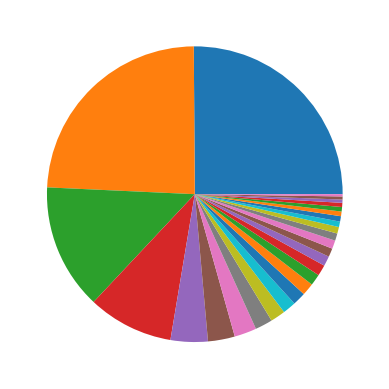

In [364]:
plt.pie(df['Genre'].value_counts())

In [365]:
corpus = new_df['Discription'].tolist()

In [366]:
# corpus

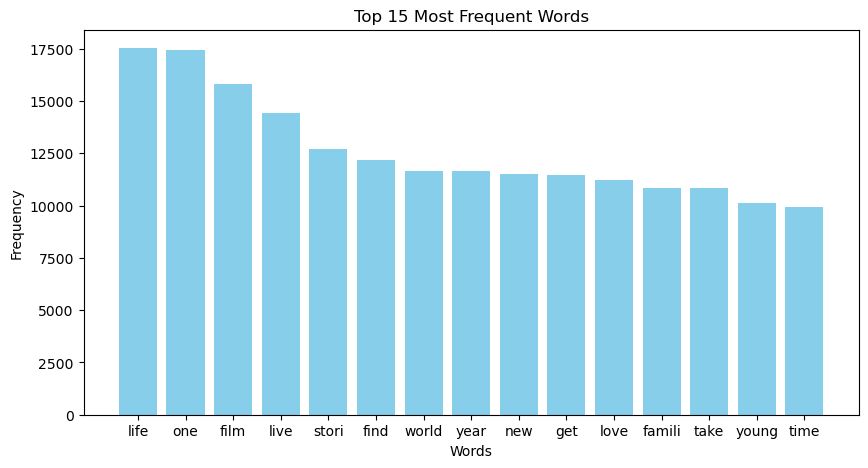

In [367]:
from collections import Counter
import matplotlib.pyplot as plt
import string
from nltk.corpus import stopwords

# Example corpus
corpus = new_df['Discription'].tolist()

# Check if the corpus is empty
if not corpus or all(not text.strip() for text in corpus):
    print("The corpus is empty or contains only whitespace!")
else:
    # Clean and preprocess the corpus
    stop_words = set(stopwords.words('english'))  # English stopwords
    cleaned_corpus = [
        ' '.join(
            word.lower().strip(string.punctuation) 
            for word in text.split() 
            if word.lower() not in stop_words
        )
        for text in corpus
    ]

    # Tokenize all words in the corpus
    all_words = ' '.join(cleaned_corpus).split()

    # Count word frequencies
    word_counts = Counter(all_words)
    common_words = word_counts.most_common(15)  # Top 15 words

    # Separate words and their counts
    words, counts = zip(*common_words)

    # Plot the bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='skyblue')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title('Top 15 Most Frequent Words')
    plt.show()

In [368]:
from wordcloud import WordCloud

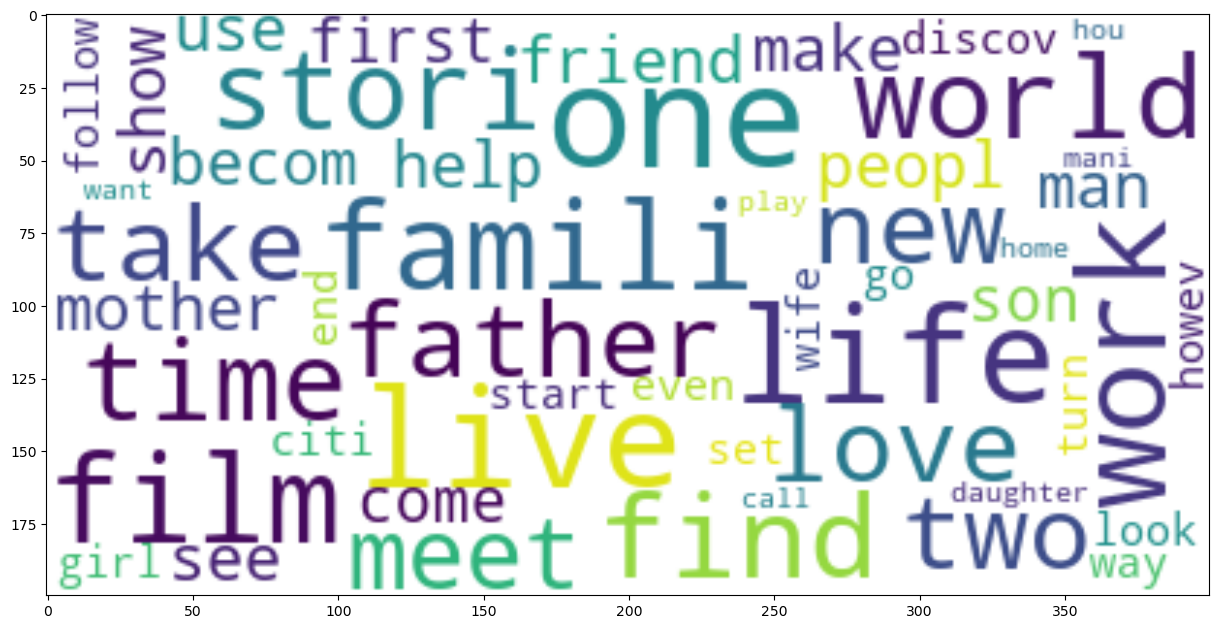

In [369]:
plt.figure(figsize=(15,10))
wordcloud = WordCloud(max_font_size=50, max_words=50, background_color="white").generate(str(corpus))
plt.imshow(wordcloud, interpolation="bilinear")

In [370]:
df.head()

,id,Movi_title,Discription,Genre,len_char,len_word,len_sent.
0,1,Oscar et la dame rose (2009),Listening in to a conversation between his do...,drama,546,105,4
1,2,Cupid (1997),A brother and sister with a past incestuous r...,thriller,184,34,2
2,3,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...,adult,650,129,7
3,4,The Secret Sin (1915),To help their unemployed father make ends mee...,drama,1082,216,9
4,5,The Unrecovered (2007),The film's title refers not only to the un-re...,drama,625,115,3


In [371]:
df.shape

(54214, 7)

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [96]:
tfidf = TfidfVectorizer(max_features=5000)
cvec = CountVectorizer(max_features=1000)

In [97]:
X = tfidf.fit_transform(df['Discription']).toarray()

In [98]:
X = X.reshape((X.shape[0], 1, X.shape[1]))

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [102]:
y.shape

(54214, 24)

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB , GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report,precision_score,f1_score,confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss
from sklearn.metrics import roc_auc_score

In [128]:
# Define model
model = Sequential()
model.add(LSTM(units=32, input_shape=(1, X.shape[2]), return_sequences=True))  # First LSTM layer
model.add(Dropout(0.4))
model.add(LSTM(units=64, return_sequences=True))  # Second LSTM layer
model.add(Dropout(0.3))
model.add(LSTM(units=128, return_sequences=True))  # Third LSTM layer
model.add(Dropout(0.3))
model.add(LSTM(units = 256,return_sequences=False))
model.add(Dense(units=24, activation='sigmoid'))  # Output layer

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy','precision','recall','auc'])

# Print model summary
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                       │ (None, 1, 32)               │         644,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 1, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_39 (LSTM)                       │ (None, 1, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_40 (LSTM)                       │ (None, 1, 128)              │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_41 (LSTM)                       │ (None, 256)                 │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 24)                  │           6,168 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,168,280 (4.46 MB)

 Trainable params: 1,168,280 (4.46 MB)

 Non-trainable params: 0 (0.00 B)

In [129]:
history = model.fit(X_train,y_train,batch_size=32,validation_split=0.2,epochs=10,verbose=1)

Epoch 1/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.8535 - auc: 0.8486 - loss: 0.4395 - precision: 0.6996 - recall: 0.6125 - val_accuracy: 1.0000 - val_auc: 0.8901 - val_loss: 0.3742 - val_precision: 0.6976 - val_recall: 0.7157
Epoch 2/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9993 - auc: 0.8925 - loss: 0.3711 - precision: 0.6967 - recall: 0.7362 - val_accuracy: 0.9999 - val_auc: 0.8965 - val_loss: 0.3657 - val_precision: 0.7061 - val_recall: 0.7689
Epoch 3/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9993 - auc: 0.9005 - loss: 0.3597 - precision: 0.7184 - recall: 0.7593 - val_accuracy: 0.9999 - val_auc: 0.9029 - val_loss: 0.3573 - val_precision: 0.7387 - val_recall: 0.7266
Epoch 4/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9992 - auc: 0.9086 - loss: 0.3483 - precision: 0.7482 - recall: 0.7360 - val_accuracy: 0.9997 - val_auc: 0.9050 - val_loss: 0.3539 - val_precision: 0.7591 - val_recall: 0.6950
Epoch 5/10
1085/

In [130]:
model.evaluate(X_train,y_train)

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 1.0000 - auc: 0.9464 - loss: 0.2675 - precision: 0.8609 - recall: 0.7486


[0.27975285053253174,
 1.0,
 0.8493225574493408,
 0.7400667667388916,
 0.9413029551506042]

In [71]:
# # # Step 4: Train Model       gnb<bnb<mnb
# model = MultiOutputClassifier(RandomForestClassifier((n_estimators=50, random_state=2))
# model.fit(X_train, y_train)

In [ ]:
from sklearn.linear_model import LogisticRegression
# Step 4: Logistic Regression for Multi-Label Classification
from sklearn.multioutput import MultiOutputClassifier

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['Genre'])

In [388]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss

# For single-label classification
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')  # or 'macro', 'weighted'
recall = recall_score(y_test, y_pred, average='micro')  # or 'macro', 'weighted'
f1 = f1_score(y_test, y_pred, average='micro')  # or 'macro', 'weighted'

# For multi-label classification
hamming = hamming_loss(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Hamming Loss: {hamming:.2f}")

Accuracy: 0.30
Precision: 0.77
Recall: 0.75
F1 Score: 0.76
Hamming Loss: 0.15
